# Notebook for Siamese LSTM AUTOENCODER

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, AdamW

import pickle
from datetime import datetime
import time


## HELPER FUNCTIONS

In [3]:
# FUNCTION TO PREDICT UNSEEN SEQUENCES

def predict_reconstructed_sequences(network, sequence_a, sequence_b):
    combined_prediction = network.predict([sequence_a, sequence_b])
    half = combined_prediction.shape[1] // 2

    #slices the combined_prediction array to extract the first half columns
    reconstructed_sequence_a = combined_prediction[:, :half]
    
    #slices the combined_prediction array to extract the last half columns
    reconstructed_sequence_b = combined_prediction[:, half:]

    return reconstructed_sequence_a, reconstructed_sequence_b

In [4]:
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)

time_callback = TimeHistory()

## MODEL FUNCTIONS

In [5]:
# CALCULATES THE PERPENDICULAR DISTANCE 

def perp_distance(args):

    point_a1, point_a2, point_b = args
    v = point_a2 - point_a1
    w = point_b  - point_a1

    # Squared length of the segment ‖v‖²  (add ε for numerical safety)
    vv = tf.reduce_sum(tf.square(v), axis=-1, keepdims=True) + tf.keras.backend.epsilon()

    # Projection scalar t = (w·v) / (‖v‖²)  — clip to [0,1] to stay on the *segment*
    t = tf.reduce_sum(w * v, axis=-1, keepdims=True) / vv
    t_clipped = tf.clip_by_value(t, 0.0, 1.0)

    # Nearest point on the segment to point_b
    nearest = point_a1 + t_clipped * v

    # Euclidean distance ‖point_b − nearest‖
    return tf.norm(point_b - nearest, axis=-1)


In [6]:
# CALCULATES THE DISPLACEMENT LOSS

def displacement_loss(y_pred_b, y_true_a):
    # y_pred_b, y_true_a: [batch, seq_len, 2]
    a1 = y_true_a[:, :-1, :]  
    a2 = y_true_a[:, 1:, :] 
    v = a2 - a1

    # Expand for broadcasting
    p = tf.expand_dims(y_pred_b, 2) 
    a1 = tf.expand_dims(a1, 1)
    v  = tf.expand_dims(v, 1)

    w = p - a1
    vv = tf.reduce_sum(v**2, axis=-1, keepdims=True) + 1e-6
    t = tf.reduce_sum(w*v, axis=-1, keepdims=True) / vv
    t = tf.clip_by_value(t, 0.0, 1.0)

    nearest = a1 + t * v
    dists = tf.norm(p - nearest, axis=-1)
    min_dists = tf.reduce_min(dists, axis=-1)
    return tf.reduce_mean(min_dists)


In [ ]:
def combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, alpha):
    y_true_a = tf.cast(y_true_a, tf.float32)
    y_true_b = tf.cast(y_true_b, tf.float32)
    y_pred_a = tf.cast(y_pred_a, tf.float32)
    y_pred_b = tf.cast(y_pred_b, tf.float32)

    mse_loss_a = tf.reduce_mean(tf.square(y_true_a - y_pred_a))
    mse_loss_b = tf.reduce_mean(tf.square(y_true_b - y_pred_b))

    disp_loss = displacement_loss(y_pred_b, y_true_a)

    # Optional debug
    #tf.print(' MSE A:', mse_loss_a, ' MSE B:', mse_loss_b, ' Disp:', disp_loss)

    C = tf.stop_gradient(tf.reduce_mean(disp_loss))  # or a fixed scalar
    return mse_loss_a + mse_loss_b + alpha * (C - disp_loss)
    #return mse_loss_a + mse_loss_b - (alpha * disp_loss)

def siamese_loss_wrapper(alpha):
    def siamese_loss(y_true, y_pred):
        num_points = tf.shape(y_pred)[1] // 2

        y_true_a = y_true[:, :num_points, :]
        y_true_b = y_true[:, num_points:, :]
        y_pred_a = y_pred[:, :num_points, :]
        y_pred_b = y_pred[:, num_points:, :]

        return combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, alpha)
    return siamese_loss

In [8]:
# FUNCTION TO CREATE THE SIAMESE DATASET 
def make_siamese_dataset(a_noisy, b_noisy, a_clean, b_clean, shuffle=False, batch_size=32):
    inputs = (a_noisy, b_noisy)

    targets = np.stack([a_clean, b_clean], axis=1)  # shape: (N, 2, 64, 2) N = 1000

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)

    return dataset.batch(batch_size)

## LOADING DATA

In [9]:
# PATH_TRAINING_A = '../data/final_dataset/sequence/normalized_local_original.npy'
# PATH_TRAINING_B =  '../data/final_dataset/sequence/normalized_local_close.npy'
# PATH_TRAINING_A_CLEAN = '../data/final_dataset/sequence/normalized_local_original.npy'
# PATH_TRAINING_B_CLEAN = '../data/final_dataset/sequence/normalized_local_far.npy'

PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_local_newsyn2_original.npy'
PATH_TRAINING_B =  '../data/preprocessing/normalized/normalized_local_newsyn2_close.npy'
PATH_TRAINING_A_CLEAN = '../data/preprocessing/normalized/normalized_local_newsyn2_original.npy'
PATH_TRAINING_B_CLEAN = '../data/preprocessing/normalized/normalized_local_newsyn2_far.npy'

# Load full arrays
lines_a_noisy = np.load(PATH_TRAINING_A)
lines_b_noisy = np.load(PATH_TRAINING_B)
lines_a_clean = np.load(PATH_TRAINING_A_CLEAN)
lines_b_clean = np.load(PATH_TRAINING_B_CLEAN)

# Total number of samples
n_total = lines_a_noisy.shape[0]

# Compute split indices
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

# --- TRAIN ---
train_slice = slice(0, n_train)
lines_a_noisy_train = lines_a_noisy[train_slice]
lines_b_noisy_train = lines_b_noisy[train_slice]
lines_a_clean_train = lines_a_clean[train_slice]
lines_b_clean_train = lines_b_clean[train_slice]

# --- VALIDATION ---
val_slice = slice(n_train, n_train + n_val)
lines_a_noisy_val = lines_a_noisy[val_slice]
lines_b_noisy_val = lines_b_noisy[val_slice]
lines_a_clean_val = lines_a_clean[val_slice]
lines_b_clean_val = lines_b_clean[val_slice]

# --- TEST ---
test_slice = slice(n_train + n_val, n_total)
lines_a_noisy_test = lines_a_noisy[test_slice]
lines_b_noisy_test = lines_b_noisy[test_slice]
lines_a_clean_test = lines_a_clean[test_slice]
lines_b_clean_test = lines_b_clean[test_slice]

# Create training, validation, and test datasets
train_dataset = make_siamese_dataset(lines_a_noisy, lines_b_noisy, lines_a_clean, lines_b_clean, shuffle=False)
val_dataset   = make_siamese_dataset(lines_a_noisy_val, lines_b_noisy_val, lines_a_clean_val, lines_b_clean_val, shuffle=False)
test_dataset  = make_siamese_dataset(lines_a_clean_test, lines_b_clean_test, lines_a_noisy_test, lines_b_noisy_test, shuffle=False)

print(f'Train: {lines_a_noisy_train.shape}, Val: {lines_a_noisy_val.shape}, Test: {lines_a_noisy_test.shape}')

Train: (35511, 64, 2), Val: (7609, 64, 2), Test: (7611, 64, 2)


2026-01-21 11:43:38.832824: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-21 11:43:38.833126: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-21 11:43:38.833141: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-21 11:43:38.833425: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-21 11:43:38.833482: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
# SAVING TEST DATASET
# with open(f'../data/final_dataset/sequence/siamese_newsyn2_test_dataset.pkl', 'wb') as f:
#     pickle.dump({
#         "siamese_test_clean_a": lines_a_clean_test,
#         "siamese_test_clean_b": lines_b_clean_test,
#         "siamese_test_noisy_a": lines_a_noisy_test,
#         "siamese_test_noisy_b": lines_b_noisy_test
#     }, f)

## CREATING MODEL

In [17]:
# LOADING PRETRAINED AE 
pretrained_autoencoder = tf.keras.models.load_model(
    #'../checkpoints/autoencoder/model/2312_bestModel_32_batches_150_epochs.keras',
    '../checkpoints/autoencoder/model/2001_1323_mse_local_finetuned_bidrectional_newsyn2_32_batches_150_epochs.keras',
    compile=False
)

for layer in pretrained_autoencoder.layers:
    layer.trainable = True

input_shape = (lines_a_noisy_train.shape[1], lines_a_noisy_train.shape[2])
input_sequence_a = Input(shape=input_shape, name='line_a_input')
input_sequence_b = Input(shape=input_shape, name='line_b_input')

reconstructed_sequence_a = pretrained_autoencoder(input_sequence_a)
reconstructed_sequence_b = pretrained_autoencoder(input_sequence_b)

siamese_output = Concatenate(axis=1)([reconstructed_sequence_a, reconstructed_sequence_b])

lines_combined = np.concatenate([lines_a_clean_train, lines_b_clean_train], axis=1)
val_lines_combined = np.concatenate([lines_a_clean_val, lines_b_clean_val], axis=1)


In [18]:
siamese_autoencoder = Model(
    inputs=[input_sequence_a, input_sequence_b],
    outputs=siamese_output,
    name='siamese_autoencoder'
)

In [23]:
# TRAINING SETUP AND PARAMETERS

description = 'BO_NewSynData_NewAE_C'
loss = siamese_loss_wrapper(0.001)
epochs = 10
batch_size= 16 #32
timestamp = datetime.now().strftime("%Y%m%d-%H%M")

CHECKPOINT_CALLBACK = f'../checkpoints/siamese/weights/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.weights.h5'

#Checkpoint callback: saves models weights, when loss is smaller than before
checkpoint_callback = ModelCheckpoint(
    filepath= CHECKPOINT_CALLBACK,
    monitor='loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

# Prevents model from overfitting due to early stopping 
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=30,
    min_delta=1e-5,
    restore_best_weights=True,
    verbose=1
)

# Tensorboard_Callback
log_dir = "../checkpoints/siamese/logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

optimizer = tf.keras.optimizers.AdamW(learning_rate=0.0032905328949595024) #3.58e-3. 1e-4
siamese_autoencoder.compile(optimizer=optimizer, loss=loss, metrics=['accuracy', 'mse', 'mae'])


# TRAINING 

In [ ]:
# TRAINING THE MODEL 
start_time = time.time()

history = siamese_autoencoder.fit(
    [lines_a_noisy_train, lines_b_noisy_train], lines_combined,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(
      [lines_a_noisy_val, lines_b_noisy_val], val_lines_combined
    ),
    callbacks=[checkpoint_callback, early_stopping_callback, tensorboard_callback, time_callback])

total_time = time.time() - start_time
epochs_to_convergence = early_stopping_callback.stopped_epoch

print("Avg time per epoch:", sum(time_callback.epoch_times) / len(time_callback.epoch_times))
print("Total elapsed time:", total_time)
print("Numnber of epochs until convergence: ", epochs_to_convergence)
siamese_autoencoder.load_weights(filepath=CHECKPOINT_CALLBACK)
siamese_autoencoder.save(f'../checkpoints/siamese/model/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.keras')
np.save(f'../checkpoints/siamese/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.npy', history.history)

Epoch 1/10
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9885 - loss: -1.5885e-06 - mae: 0.0070 - mse: 1.2180e-04
Epoch 1: loss improved from None to -0.00001, saving model to ../checkpoints/siamese/weights/20260121-1203_BO_NewSynData_NewAE_C_16_batches_10_epochs.weights.h5
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 359s 159ms/step - accuracy: 0.9888 - loss: -1.2041e-05 - mae: 0.0069 - mse: 1.1669e-04 - val_accuracy: 0.9856 - val_loss: 1.2764e-06 - val_mae: 0.0076 - val_mse: 1.3160e-04
Epoch 2/10
1203/2220 ━━━━━━━━━━━━━━━━━━━━ 2:56 174ms/step - accuracy: 0.9892 - loss: -2.2557e-05 - mae: 0.0067 - mse: 1.1127e-04

In [ ]:
#siamese_autoencoder.summary()

In [86]:
%reload_ext tensorboard
%tensorboard --logdir ../checkpoints/siamese/logs

Reusing TensorBoard on port 6009 (pid 87140), started 0:00:33 ago. (Use '!kill 87140' to kill it.)

## BAYESIAN OPTIMIZATION

In [ ]:
def build_siamese_model(hp):

    # Hyperparameters to tune
    batch_size = hp.Choice('batch_size', [16, 32])
    
    learning_rate = hp.Float(
        'learning_rate',
        min_value=1e-5,
        max_value=1e-2,
        sampling='log'
    )

    optimizer_choice = hp.Choice(
        'optimizer',
        values=['adam', 'adamw', 'rmsprop']
    )

    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = AdamW(learning_rate=learning_rate, weight_decay=hp.Float('weight_decay', 1e-6, 1e-3, sampling='log'))

    # Load pretrained AE
    pretrained_autoencoder = tf.keras.models.load_model(
        '../checkpoints/autoencoder/model/2312_bestModel_32_batches_150_epochs.keras',
        compile=False
    )

    # Freezing
    freeze_encoder = hp.Boolean('freeze_encoder')
    if freeze_encoder:
        for layer in pretrained_autoencoder.layers:
            layer.trainable = False

    # Siamese architecture
    input_shape = (lines_a_noisy_train.shape[1],lines_a_noisy_train.shape[2])

    input_sequence_a = Input(shape=input_shape, name='line_a_input')
    input_sequence_b = Input(shape=input_shape, name='line_b_input')

    reconstructed_a = pretrained_autoencoder(input_sequence_a)
    reconstructed_b = pretrained_autoencoder(input_sequence_b)

    siamese_output = Concatenate(axis=1)(
        [reconstructed_a, reconstructed_b]
    )

    model = Model(
        inputs=[input_sequence_a, input_sequence_b],
        outputs=siamese_output,
        name='siamese_autoencoder'
    )

    model.compile(optimizer=optimizer,loss=loss)

    return model


In [ ]:
tuner = kt.BayesianOptimization(
    build_siamese_model,
    objective='val_loss',
    max_trials=20,        # number of Bayesian steps
    num_initial_points=5, # random warm-up trials
    directory='../checkpoints/siamese/tuning',
    project_name='siamese_ae_loss'
)

In [ ]:
tuner.search(
    x=[lines_a_noisy_train, lines_b_noisy_train],
    y=lines_combined,
    validation_data=(
        [lines_a_noisy_val, lines_b_noisy_val],
        val_lines_combined
    ),
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
for key in best_hp.values:
    print(f"{key}: {best_hp.get(key)}")

best_model = tuner.get_best_models(num_models=1)[0]

best_model.save(
    f'../checkpoints/siamese/model/{timestamp}_best_bayesian_model2.keras'
)


## POST-TRAINING

### PLOT HISTORY

In [87]:
def plot_history(history, epochs, batch_size, saving_img=True):
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history:
        plt.plot(history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs', fontdict={'family': 'serif', 'size': 10})
    plt.ylabel('Loss', fontdict={'family': 'serif', 'size': 10})
    plt.legend(prop={'family': 'serif', 'size': 10})
    plt.title(f'Training Loss Siamese LSTM AE {epochs} Epochs', fontdict={'family': 'serif', 'size': 14})
    plt.grid()
    plt.xticks(fontsize=10, family='serif')
    plt.yticks(fontsize=10, family='serif')

    if saving_img:
        # save figure 
        save_path = f'../checkpoints/siamese/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.png'
        #save_path = f'../checkpoints/siamese/history/2912_1106_{description}_32_batches_100_epochs.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

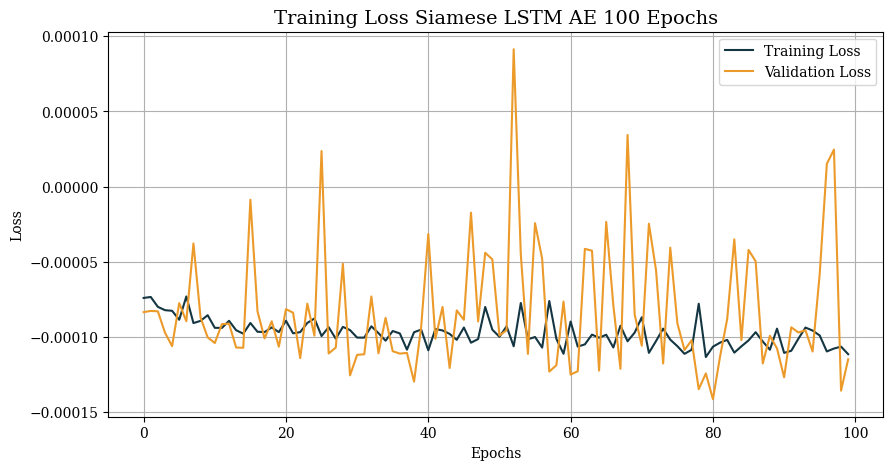

In [88]:
#history = np.load('../checkpoints/siamese/history/20260116_1052_BO_NewSynData_16_batches_50_epochs.npy', allow_pickle=True).item()
history2 = history.history
plot_history(history2, epochs, batch_size, saving_img=True)

### PLOT PREDICTIONS

In [13]:
# LOAD MODEL AND WEIGHTS 
siamese_autoencoder = tf.keras.models.load_model('../checkpoints/siamese/model/20260120-2254_BO_NewSynData_NewAE_16_batches_100_epochs.keras', custom_objects={'siamese_loss': loss})
#siamese_autoencoder = tf.keras.models.load_model(f'../checkpoints/siamese/model/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.keras', custom_objects={'siamese_loss': loss})
#siamese_autoencoder.load_weights(filepath=f'../checkpoints/siamese/weights/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.weights.h5')

In [14]:
# PREDICTION 
pred_siamese_a, pred_siamese_b = predict_reconstructed_sequences(siamese_autoencoder, lines_a_noisy_test, lines_b_noisy_test)

2026-01-21 11:44:48.288357: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step


In [15]:
# SAVE PREDICTED RESULTS 
# with open(f'../data/results/siamese/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs_predictions.pkl', 'wb') as f:
with open(f'../data/results/siamese/20260120-2254_BO_NewSynData_NewAE_16_batches_100_epochs_predictions.pkl', 'wb') as f:
    pickle.dump({
        "pred_siamese_a": pred_siamese_a,
        "pred_siamese_b": pred_siamese_b
    }, f)

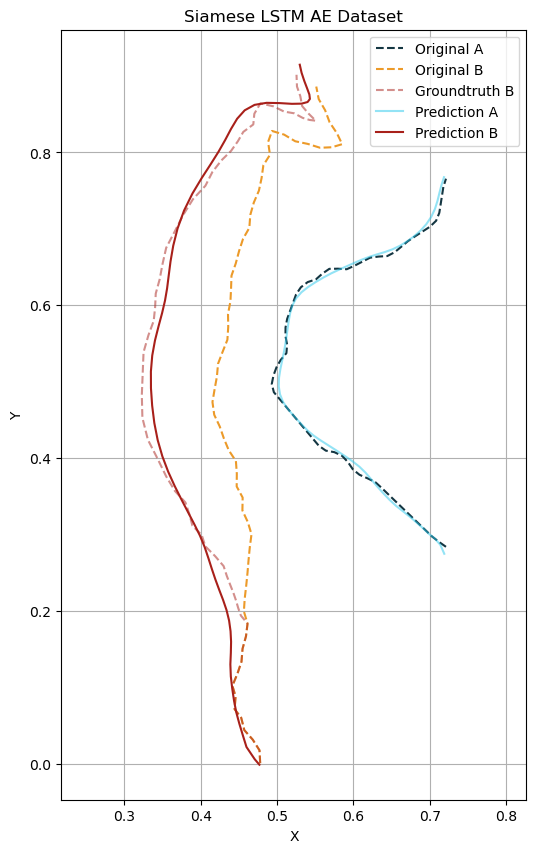

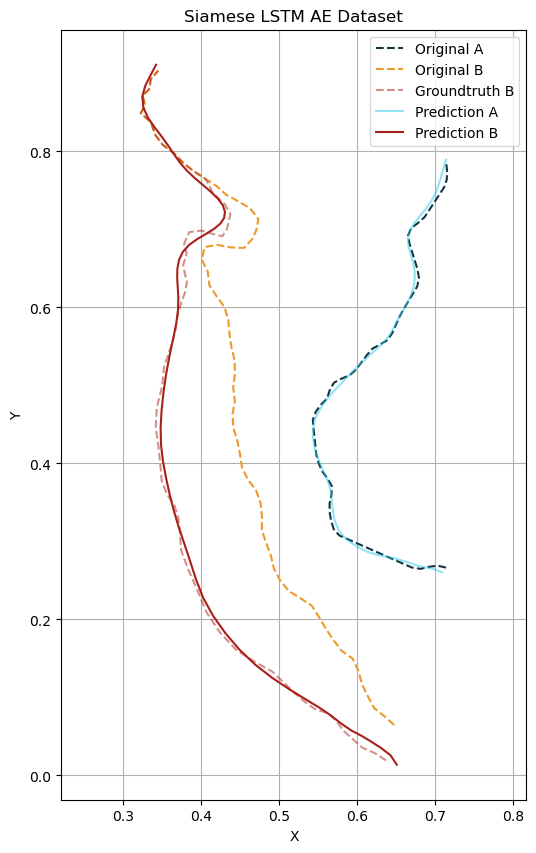

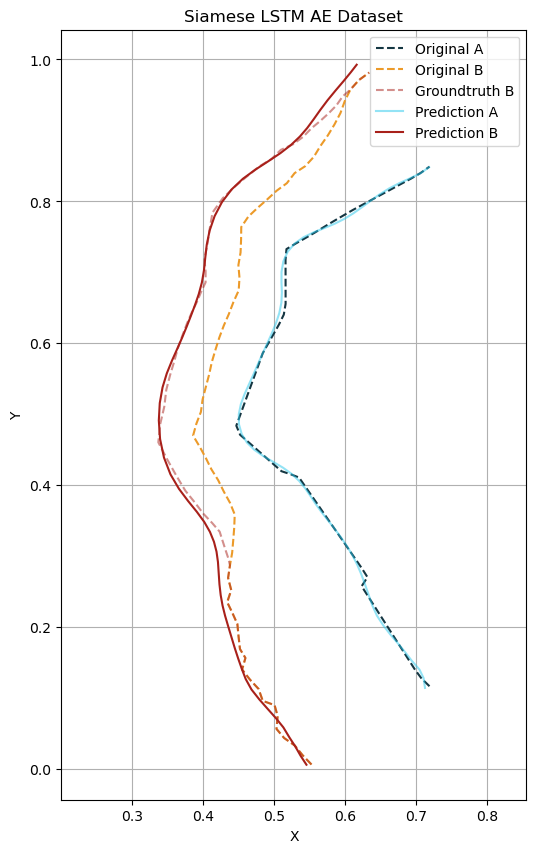

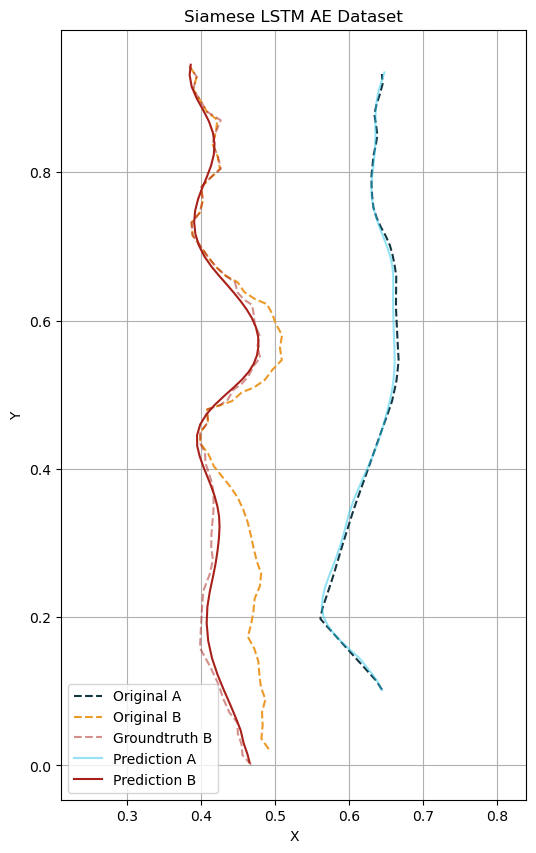

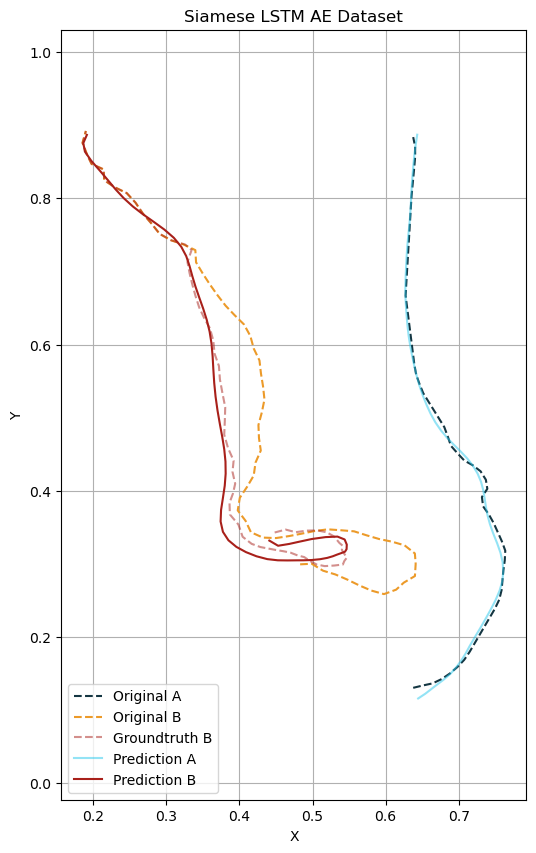

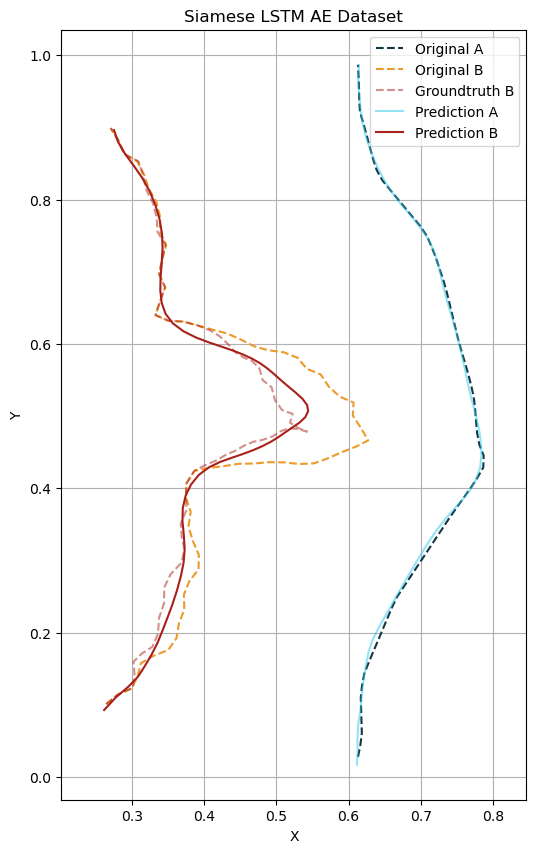

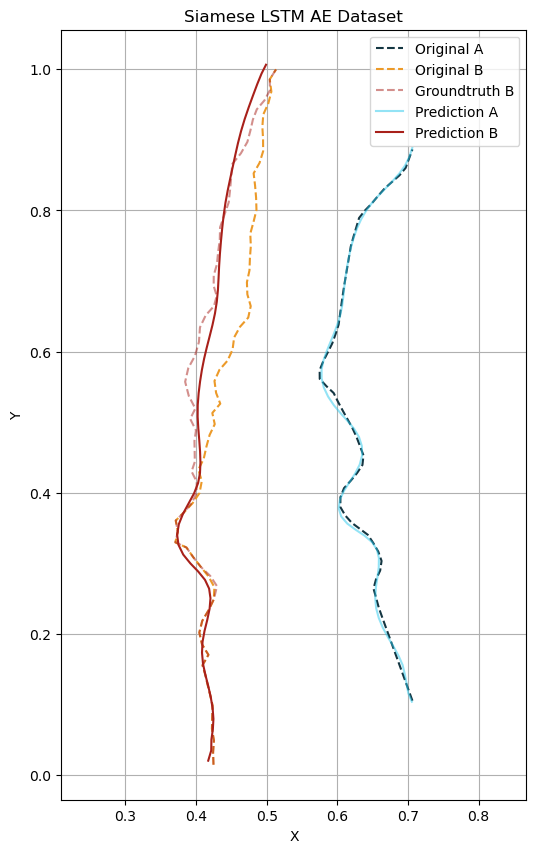

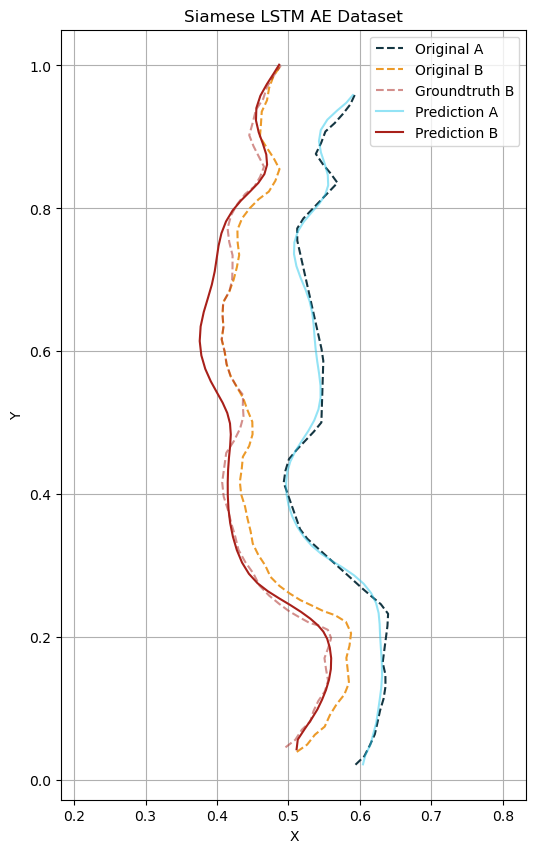

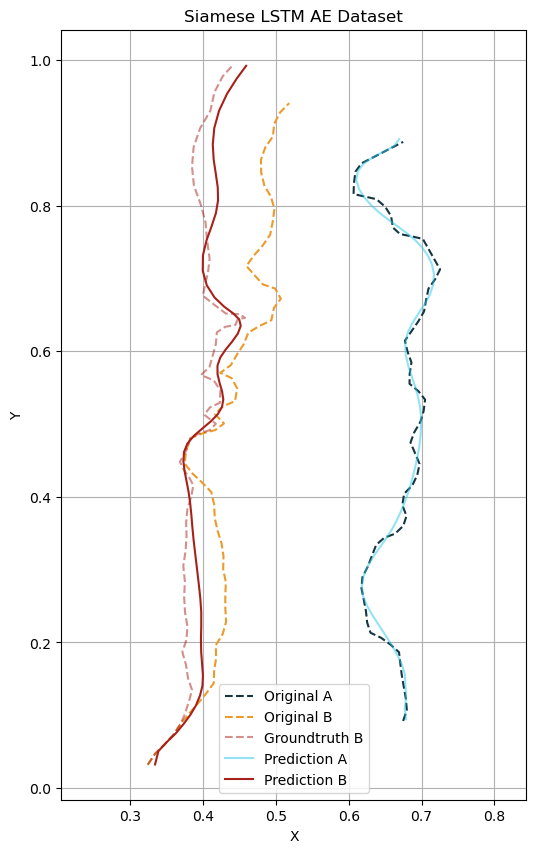

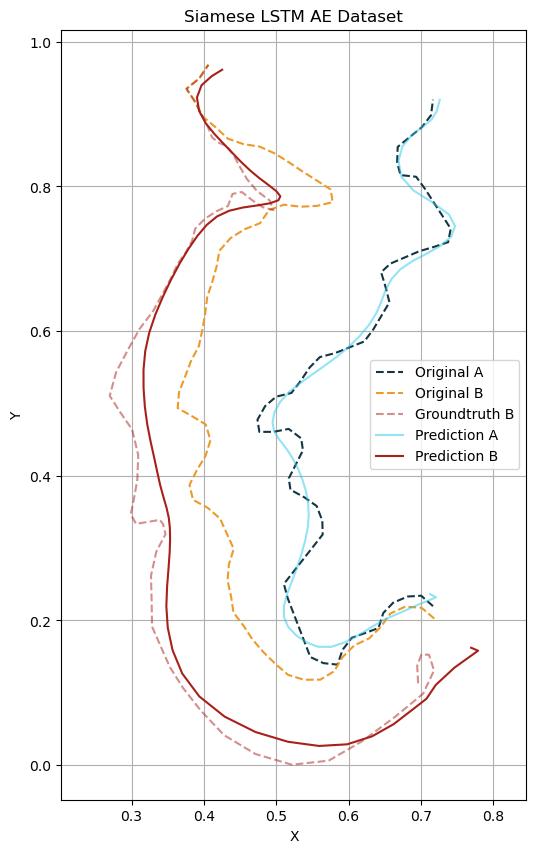

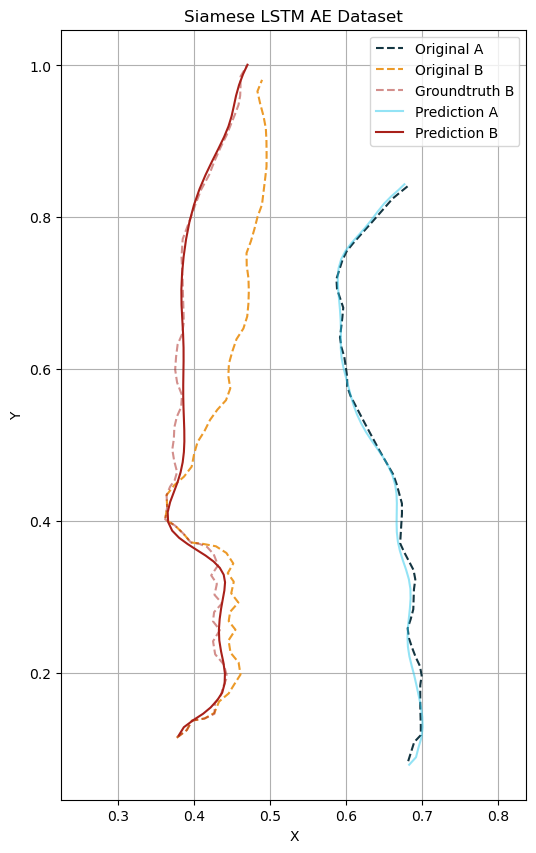

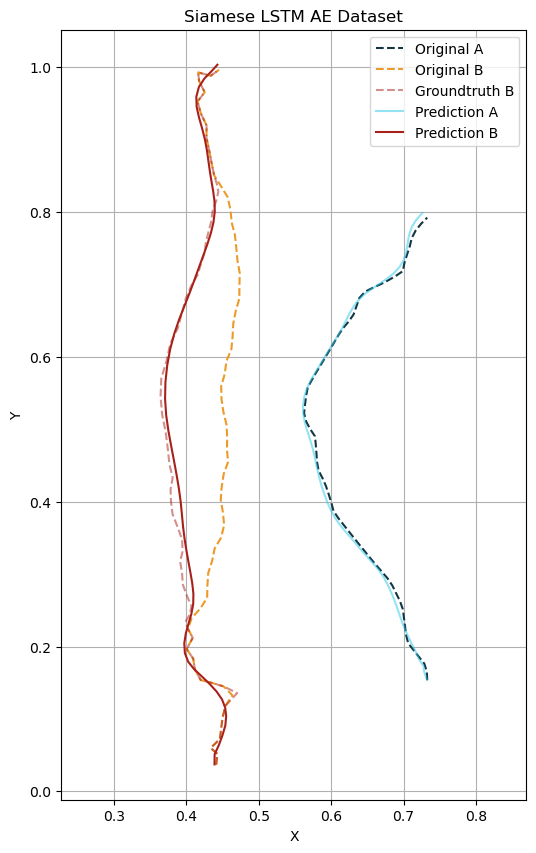

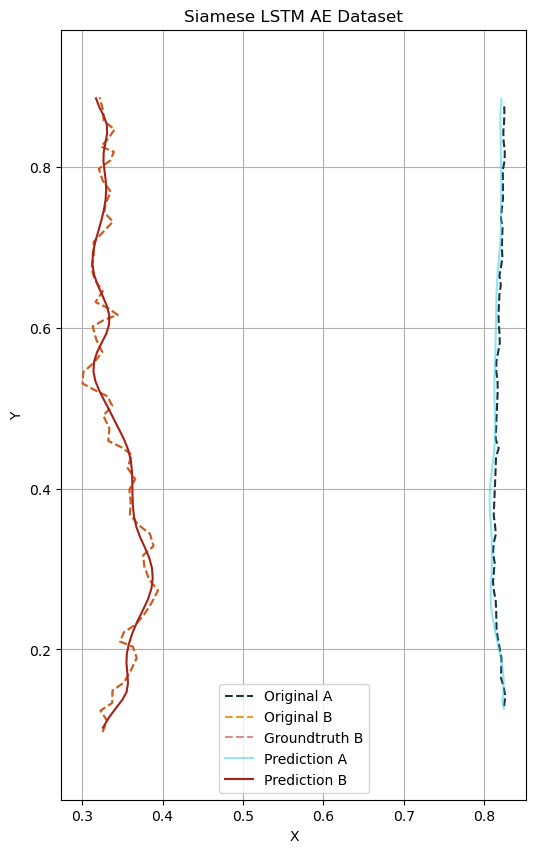

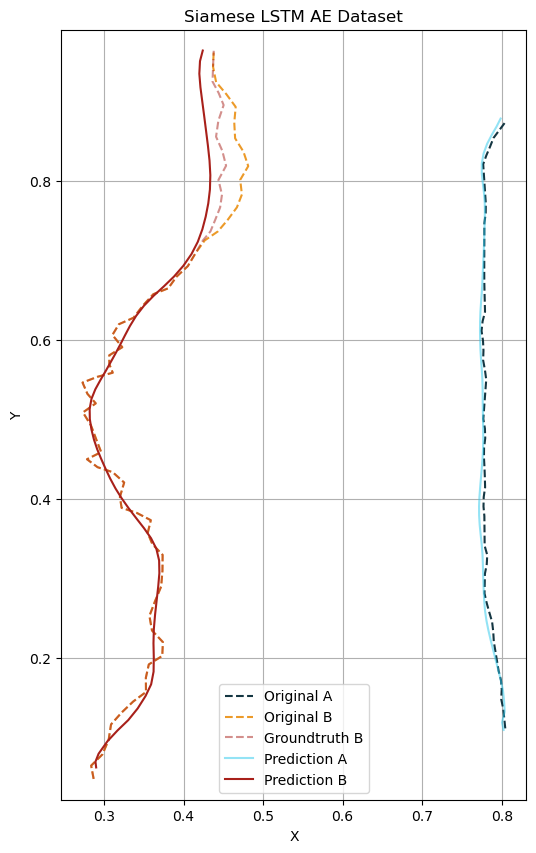

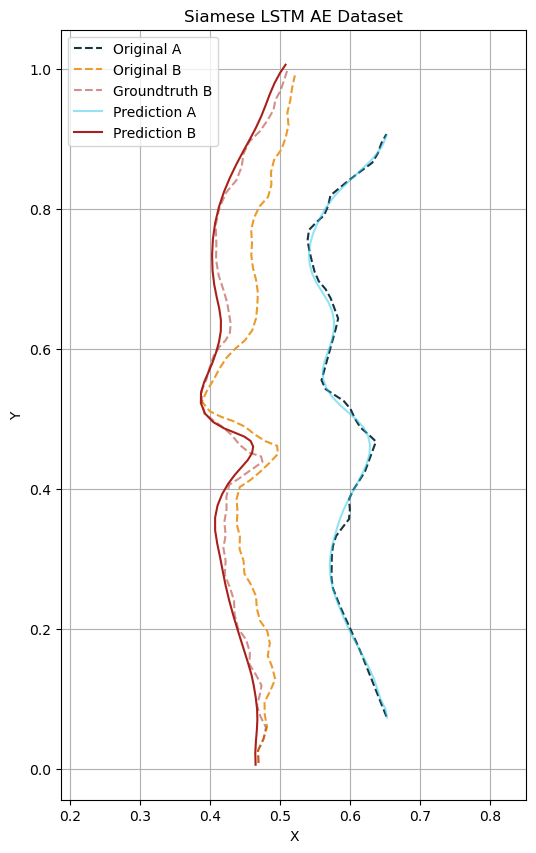

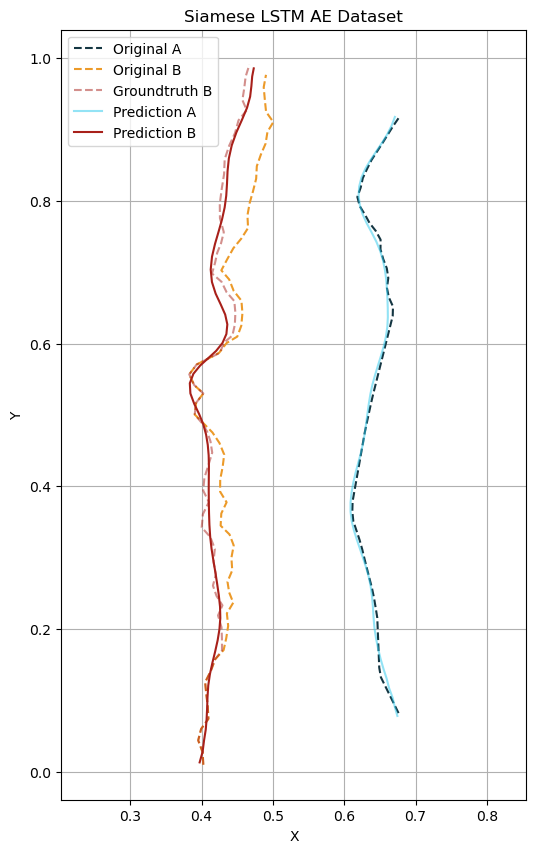

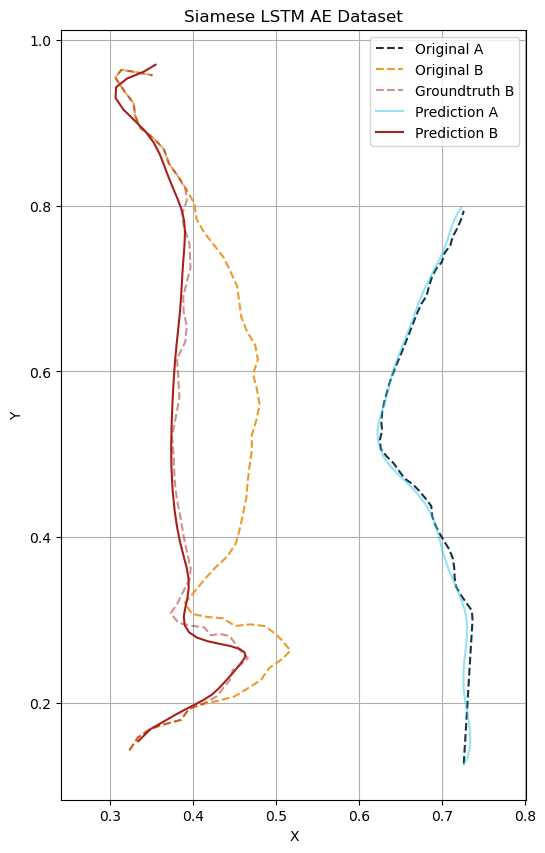

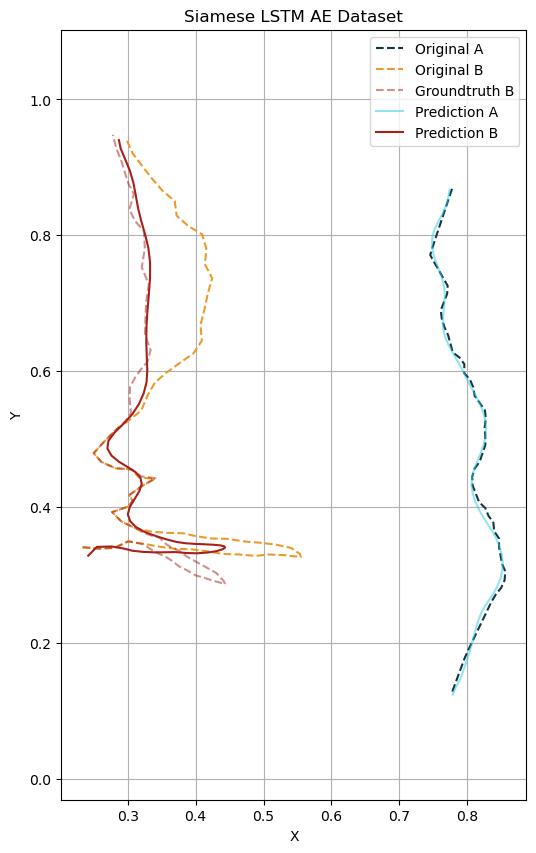

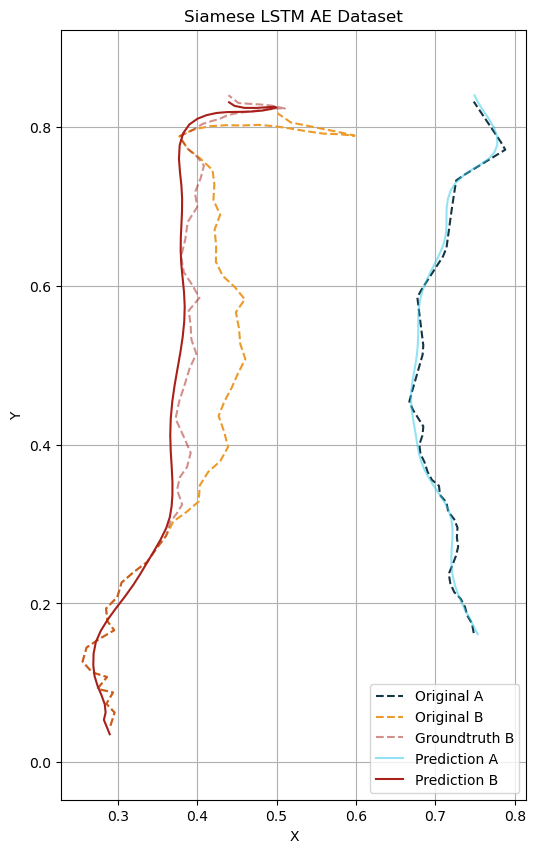

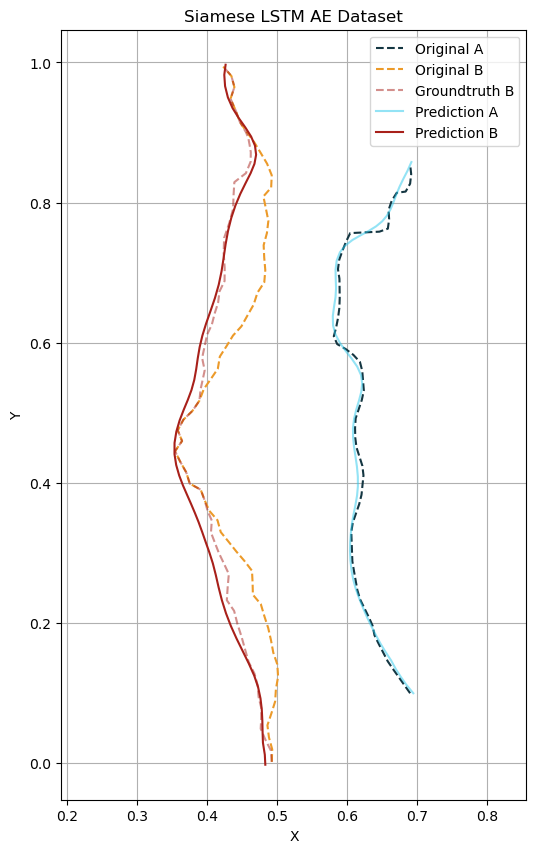

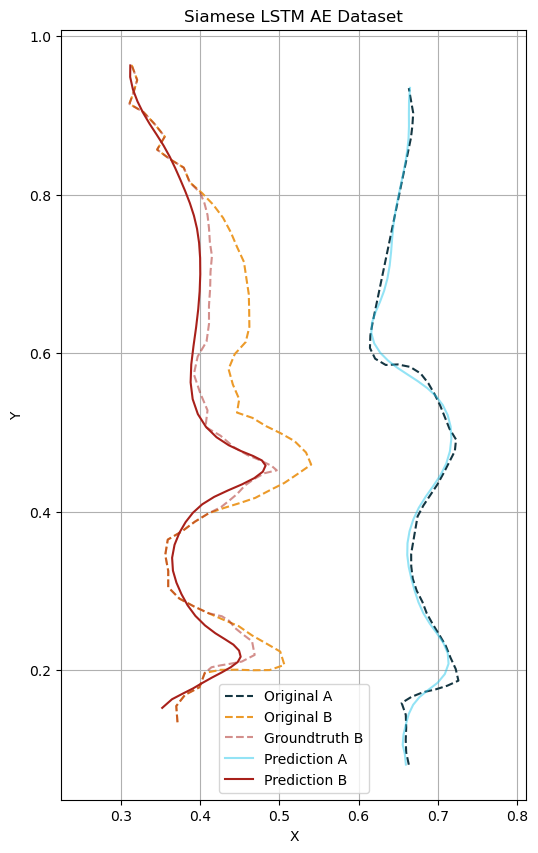

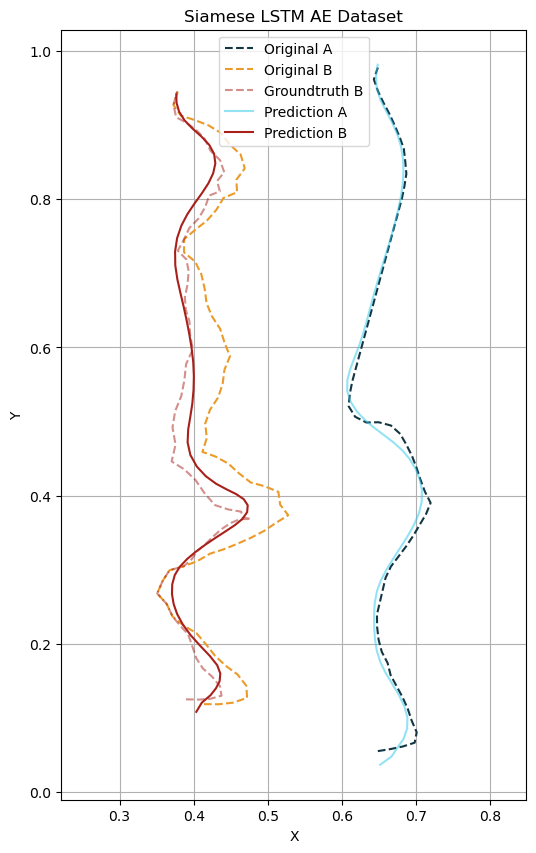

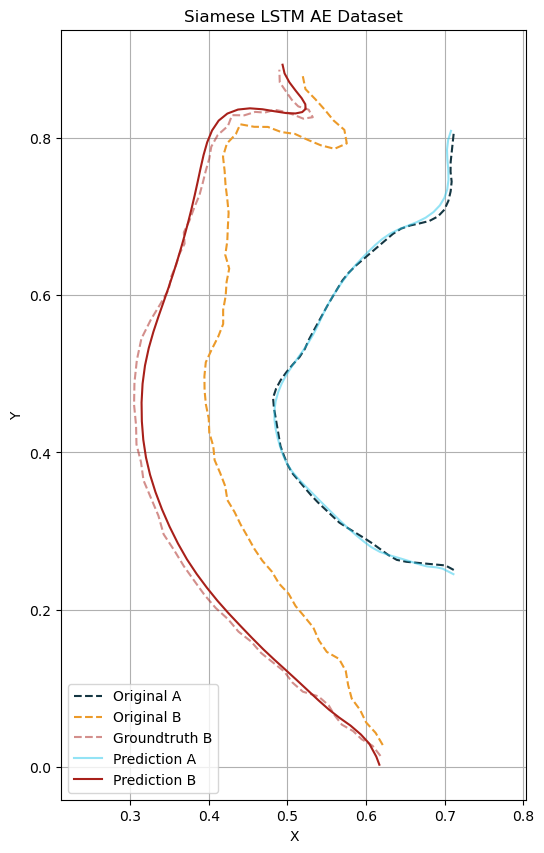

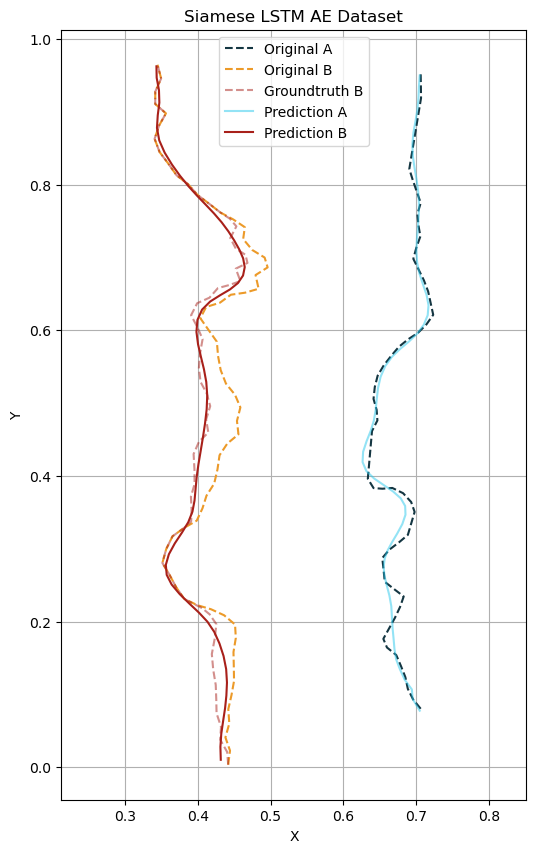

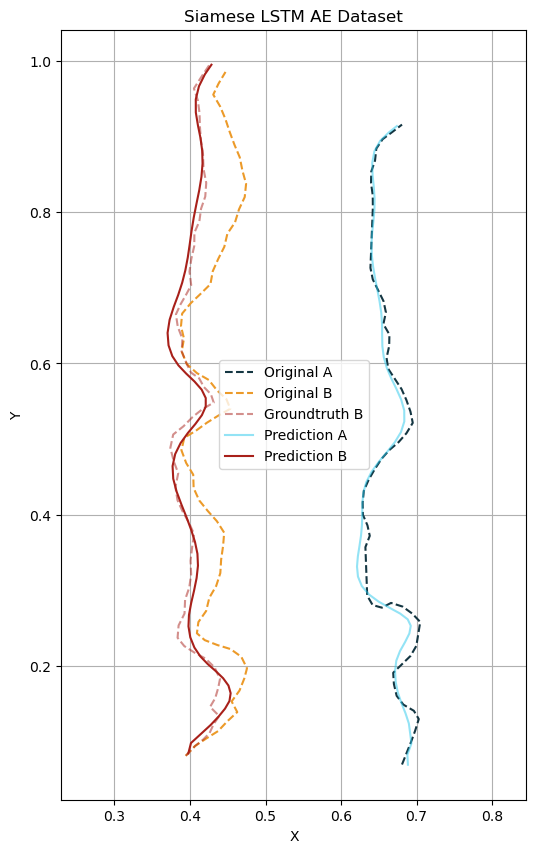

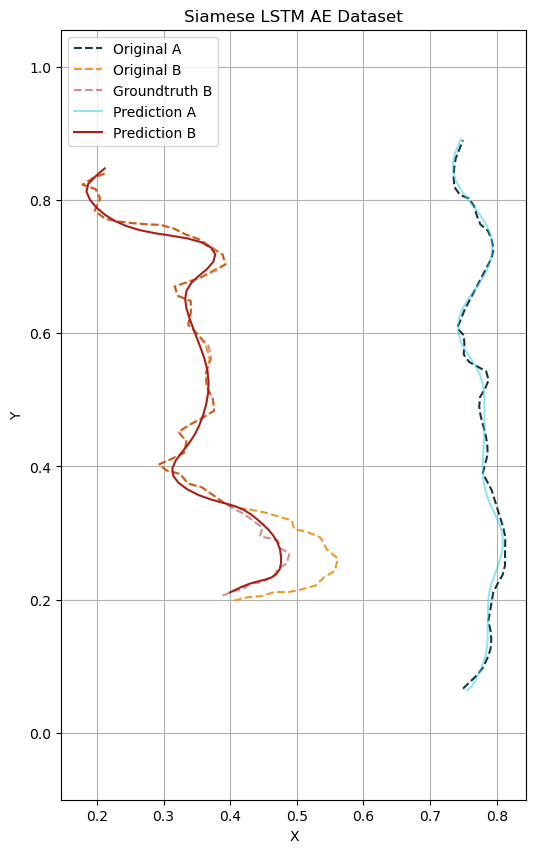

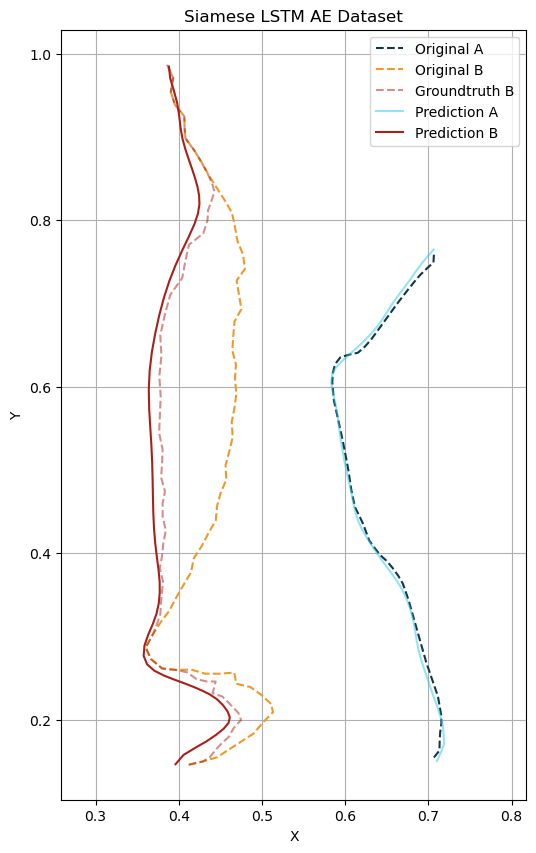

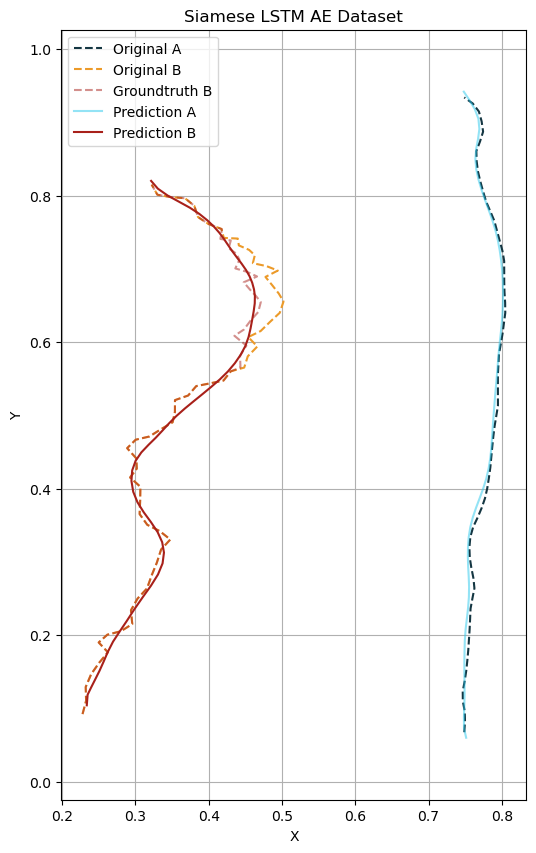

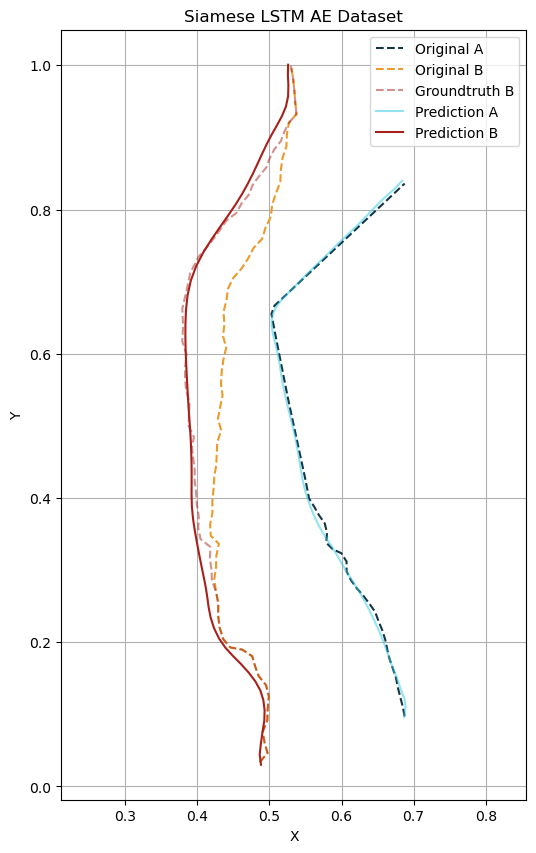

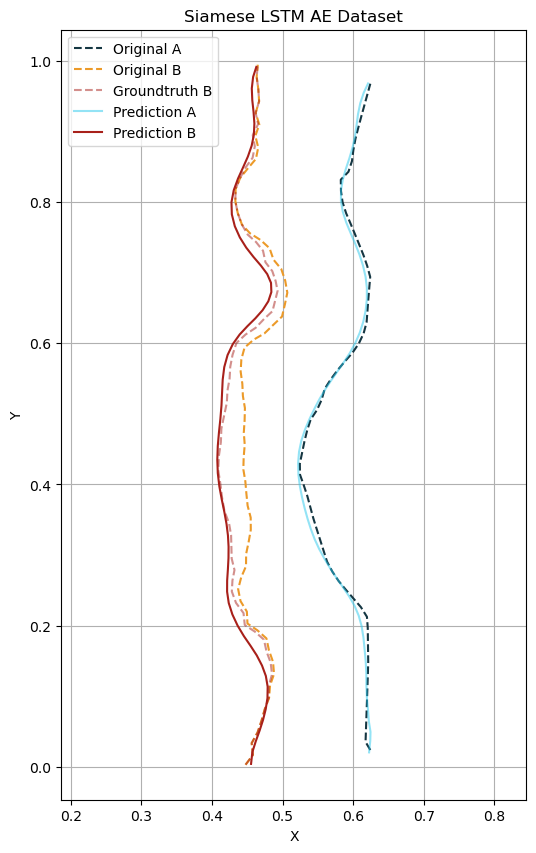

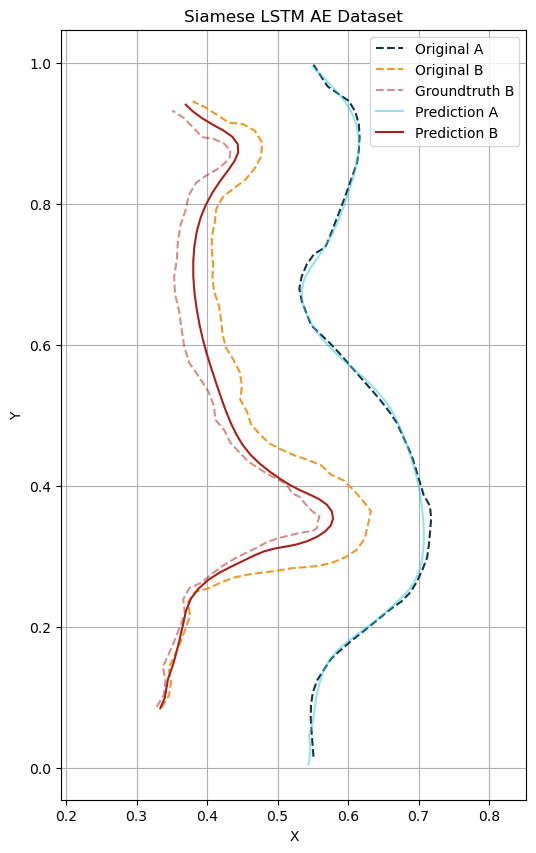

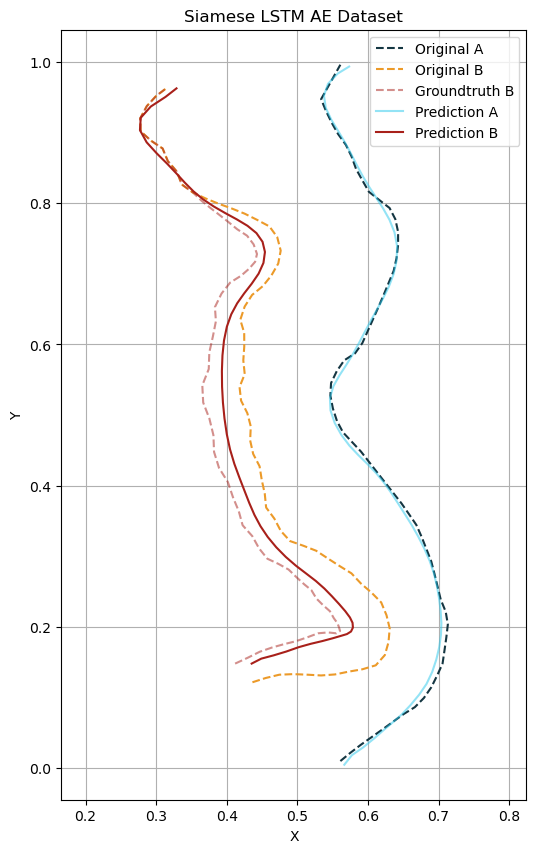

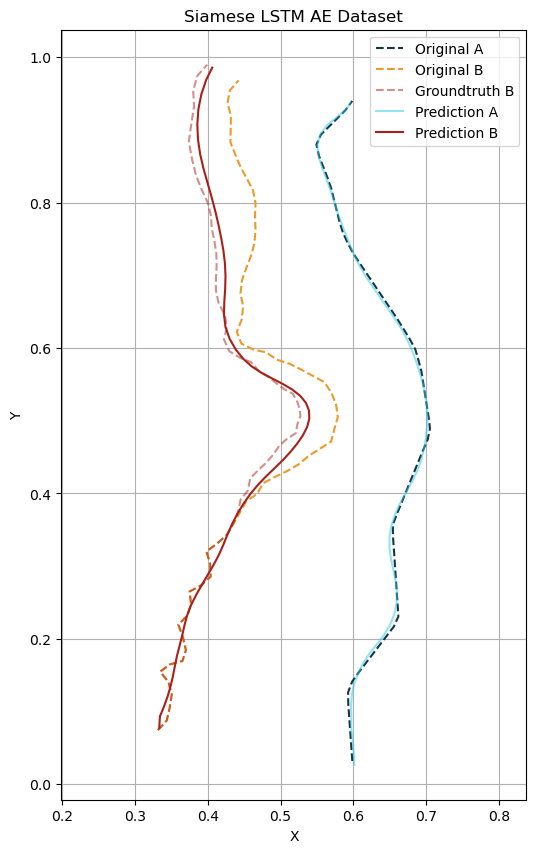

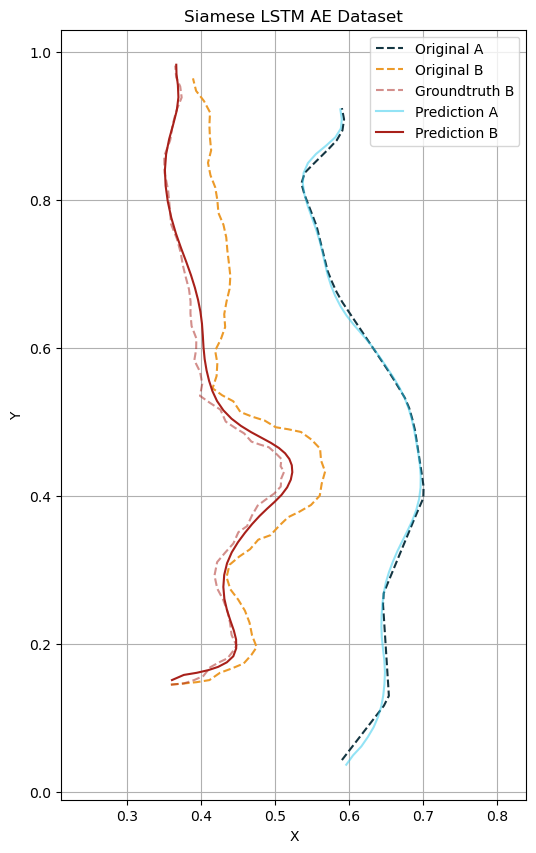

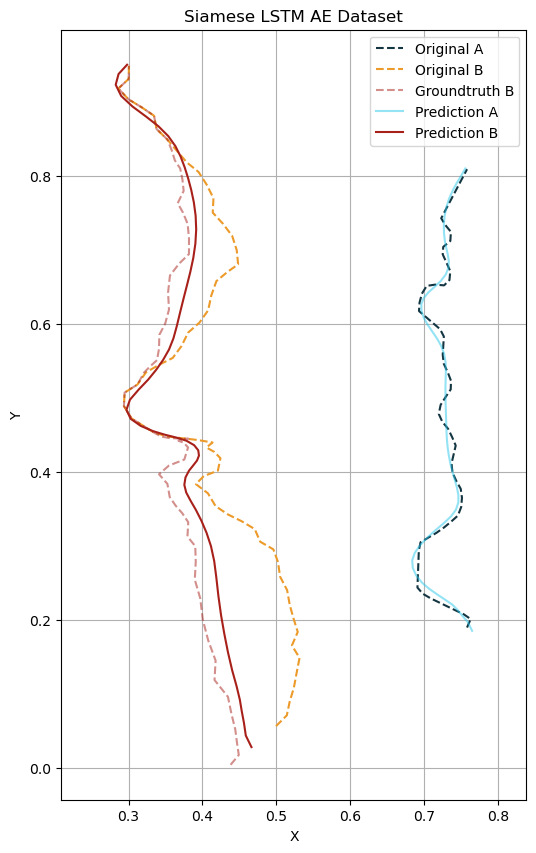

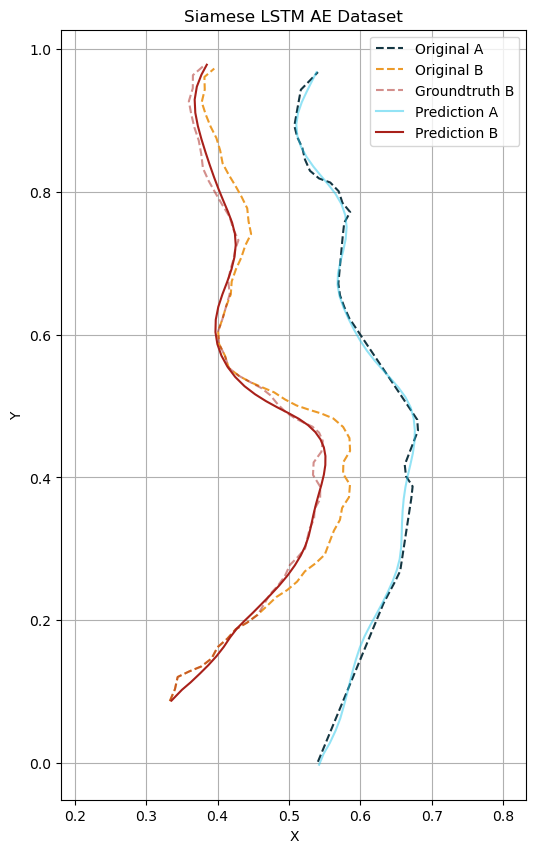

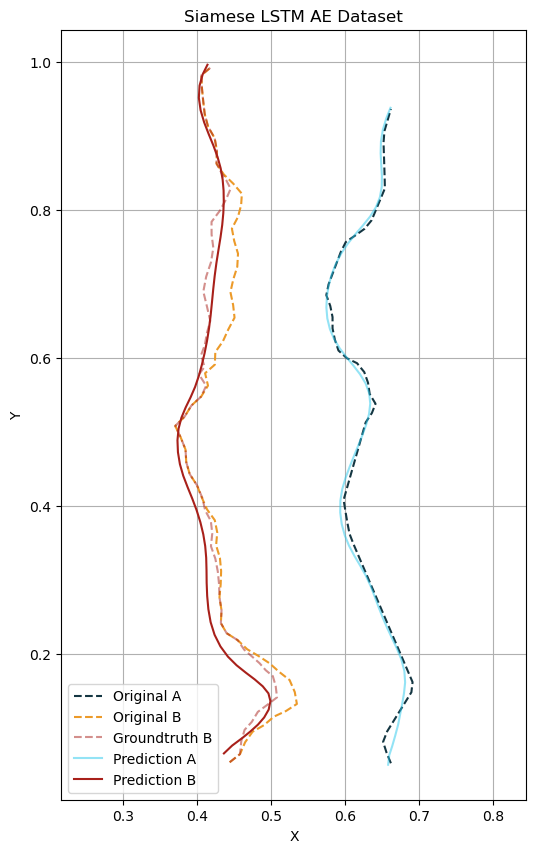

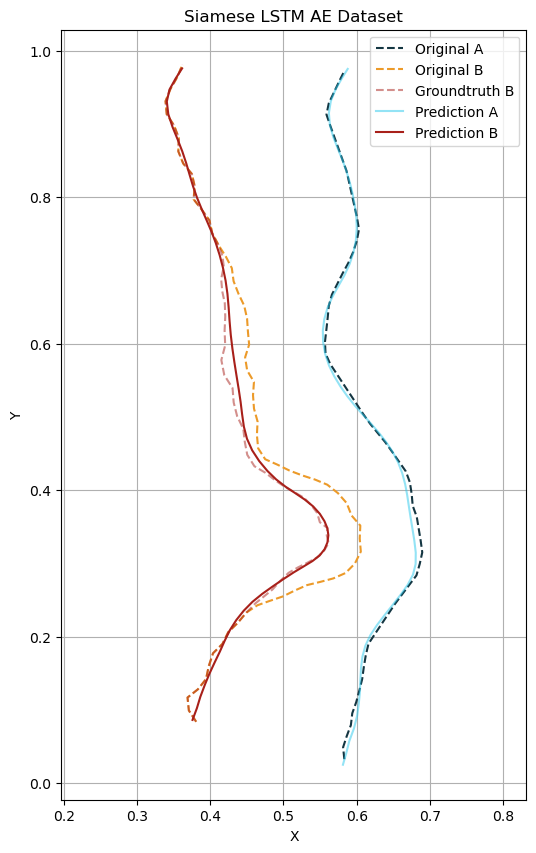

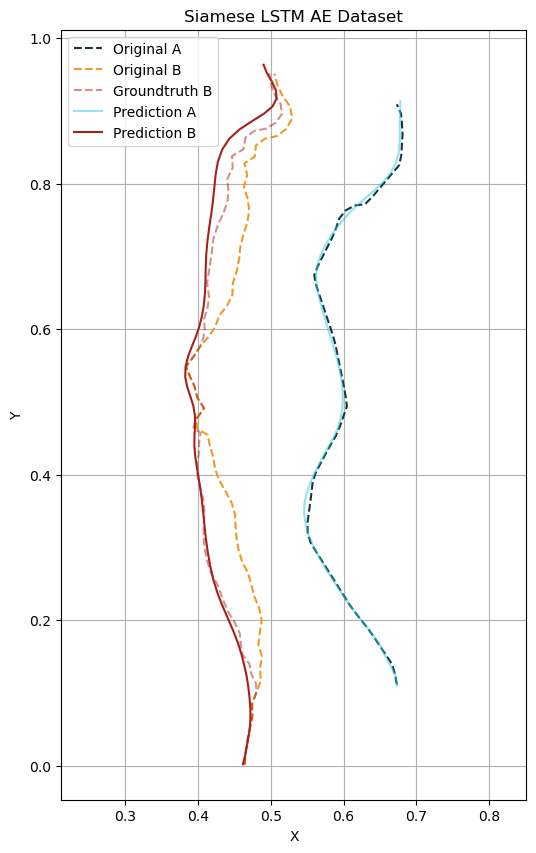

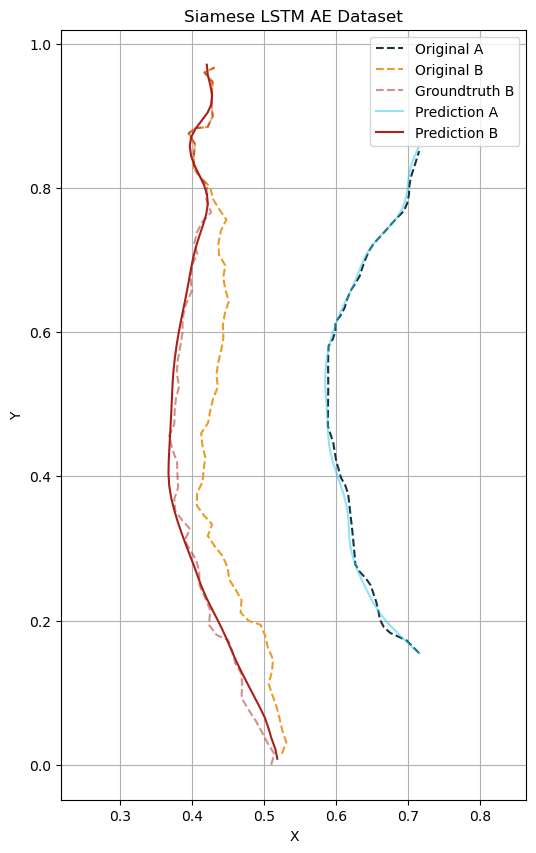

In [16]:
# PLOTTING RESULTS

for i in range(10, 50):
    plt.figure(figsize=(6, 10))
    start_plot = i
    end_plot = start_plot + 1

    # Plot training segments A
    for i, segment in enumerate(lines_a_noisy_test[start_plot:end_plot,:,:]):
        plt.plot(segment[:, 0], segment[:, 1],
                color='#143642', linestyle='--',
                label='Original A' if i == 0 else '')

    # Plot training segments B
    for i, segment in enumerate(lines_b_noisy_test[start_plot:end_plot,:,:]):
        plt.plot(segment[:, 0], segment[:, 1],
                color='#EC9A29', linestyle='--',
                label='Original B' if i == 0 else '')
        
    # Plot training segments B
    for i, segment in enumerate(lines_b_clean_test[start_plot:end_plot,:,:]):
        plt.plot(segment[:, 0], segment[:, 1],
                 color='#A8201A',  alpha=0.5, linestyle='--',
                 label='Groundtruth B' if i == 0 else '')

    # Plot predicted segments A
    for i, segment in enumerate(pred_siamese_a[start_plot:end_plot,:,:]):
        plt.plot(segment[:, 0], segment[:, 1],
                color='#29C8EC', alpha=0.5,
                label='Prediction A' if i == 0 else '')

    # Plot predicted segments B
    for i, segment in enumerate(pred_siamese_b[start_plot:end_plot,:,:]):
        plt.plot(segment[:, 0], segment[:, 1],
                color='#A8201A',
                label='Prediction B' if i == 0 else '')

    plt.title('Siamese LSTM AE Dataset')
    plt.xlabel('X')
    plt.axis('equal')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()